# 05 — Clustering Peer Groups

**Chapter 7 companion.** Benchmarking needs peers, and the usual peer sets (Carnegie
class, state, athletic conference) are defined by mission and history rather than by
how institutions actually operate. This notebook builds data-driven peer groups from
size, staffing, finance, and student-body features, and then asks what any
clustering must answer before it is used: how many groups the data supports, how
stable they are, and how far they agree with the classifications they might replace.

| | |
|---|---|
| Input | `data/analytic/institutions_2023.parquet`, four-year institutions |
| Features | `iu.PEER_FEATURES`: log enrollment, student-faculty ratio, tuition share of revenue, instruction share of expense, log expense per FTE, instructional share of staff FTE, tenure density, log average salary, share exclusively online, Pell share |
| Methods | Standardisation, k-means with silhouette, Gaussian mixtures with BIC, bootstrap stability (ARI), external validation against control and Carnegie class, structural-missingness sensitivity |
| Output | `data/analytic/peer_groups.parquet` (used by notebooks 06 and 10) |

**Comparability caveat.** Public institutions report finance under GASB and private
ones under FASB, and the standards treat scholarship allowances, pensions, and
investment returns differently. Revenue and expense ratios are close enough to
cluster on, but not identical in meaning across controls; see the
[Delta Cost Project data dictionary](https://nces.ed.gov/ipeds/deltacostproject/download/Delta_Data_Dictionary_1987_2012.xls)
for how that project adjusted them.

In [1]:
import os
import sys
import warnings
from pathlib import Path

sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import ipeds_utils as iu

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
plt.rcParams.update({
    "figure.dpi": 100, "figure.figsize": (8, 4.2),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 10,
})

ANALYTIC = Path("../data/analytic")
FIGURES = Path("../reports/figures")
ANALYTIC.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

SEED = 20231  # one seed for every stochastic step, so reruns reproduce exactly
rng = np.random.default_rng(SEED)


def save(name):
    """Save the current figure to reports/figures and display it."""
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


print(f"ipeds_utils {iu.__version__} | pandas {pd.__version__} | numpy {np.__version__}")

ipeds_utils 1.1.0 | pandas 3.0.5 | numpy 2.5.3


In [2]:
source = ANALYTIC / "institutions_2023.parquet"
if not source.exists():
    raise FileNotFoundError("Run 01_ingest_clean_deidentify.ipynb first; it builds the analytic table.")

inst = pd.read_parquet(source)
inst = inst[inst["IN_UNIVERSE"]].copy()
print(f"{len(inst):,} institutions in the analysis universe")

5,988 institutions in the analysis universe


## 1. Build the feature matrix

`iu.peer_feature_matrix` applies the transforms and drops institutions missing any
feature rather than imputing. For clustering, dropping is the conservative choice:
an imputed median places an institution at the centre of the feature space, exactly
where cluster boundaries are least stable. The coverage table shows the cost.

In [3]:
four = inst[inst["ICLEVEL"] == 1].copy()
X, coverage = iu.peer_feature_matrix(four)
print(f"{len(four):,} four-year institutions; {len(X):,} with every feature ({len(four) - len(X):,} dropped)")
coverage

2,773 four-year institutions; 2,143 with every feature (630 dropped)


,source,missing,share_missing
log_enroll,ENROLL_FALL,27,0.010
stu_fac_ratio,STUFACR,294,0.106
tuition_share,TUITION_SHARE,154,0.056
instr_exp_share,INSTR_EXP_SHARE,152,0.055
log_exp_per_fte,EXP_PER_FTE,153,0.055
instr_fte_share,INSTR_FTE_SHARE,34,0.012
tenure_density,TENURE_DENSITY,345,0.124
log_avg_salary,SALTOTL,136,0.049
pct_online,PCTE12DEEXC,12,0.004
pct_pell,UPGRNTP,300,0.108


In [4]:
from sklearn.preprocessing import StandardScaler

Z = StandardScaler().fit_transform(X)
X.describe().T[["mean", "std", "min", "50%", "max"]]

,mean,std,min,50%,max
log_enroll,3.390,0.632,1.380,3.376,5.267
stu_fac_ratio,14.131,6.413,1.000,13.000,132.000
tuition_share,0.438,0.267,0.000,0.392,1.000
instr_exp_share,0.338,0.108,0.017,0.339,0.919
log_exp_per_fte,4.522,0.295,3.181,4.497,6.350
instr_fte_share,0.394,0.107,0.062,0.390,0.917
tenure_density,0.475,0.368,0.000,0.630,1.000
log_avg_salary,4.849,0.157,3.848,4.854,5.338
pct_online,21.252,22.719,0.000,14.000,100.000
pct_pell,35.372,17.816,0.000,33.000,100.000


## 2. How many groups?

Neither criterion below gives the true number of clusters, because institutional
data has no true number. The silhouette score measures how much closer each
institution is to its own cluster than to the next one. BIC for a Gaussian mixture
trades fit against the number of parameters. Both are read alongside the practical
constraint: benchmarking needs groups small enough to be comparable and large
enough to give a stable median.

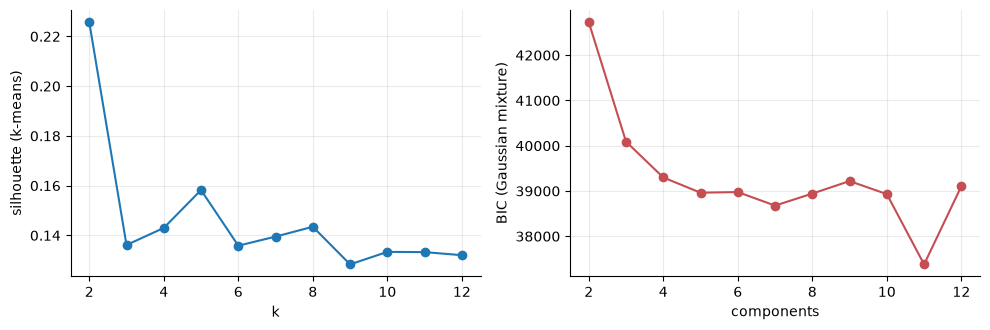

,inertia,silhouette,GMM BIC,smallest k-means cluster
k,,,,
2,"17,343.816",0.226,"42,730.365",798
3,"15,704.152",0.136,"40,091.028",597
4,"14,426.284",0.143,"39,298.873",341
5,"13,276.460",0.158,"38,962.476",180
6,"12,438.447",0.136,"38,976.545",179
7,"11,796.915",0.140,"38,677.730",149
8,"11,306.666",0.143,"38,943.081",33
9,"10,862.094",0.128,"39,219.254",29
10,"10,498.246",0.133,"38,931.093",42


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.mixture import GaussianMixture

ks = range(2, 13)
rows = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=20, random_state=SEED).fit(Z)
    gm = GaussianMixture(n_components=k, covariance_type="full", n_init=3, random_state=SEED).fit(Z)
    rows.append({"k": k, "inertia": km.inertia_, "silhouette": silhouette_score(Z, km.labels_),
                 "GMM BIC": gm.bic(Z), "smallest k-means cluster": int(np.bincount(km.labels_).min())})
selection = pd.DataFrame(rows).set_index("k")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(selection.index, selection["silhouette"], "o-")
axes[0].set(xlabel="k", ylabel="silhouette (k-means)")
axes[1].plot(selection.index, selection["GMM BIC"], "o-", color="#C44E52")
axes[1].set(xlabel="components", ylabel="BIC (Gaussian mixture)")
save("05_model_selection")
selection

In [6]:
# Peer groups need at least ~6 groups to separate missions, and at least 30
# institutions in the smallest group for a stable peer median.
eligible = selection[(selection.index >= 6) & (selection["smallest k-means cluster"] >= 30)]
K = int(eligible["silhouette"].idxmax())
print(f"chosen k = {K} (best silhouette among k >= 6 with every cluster >= 30 institutions)")
print(f"GMM BIC minimum at k = {int(selection['GMM BIC'].idxmin())}; "
      f"range of BIC across k = 5..12: {selection.loc[5:, 'GMM BIC'].max() - selection.loc[5:, 'GMM BIC'].min():,.0f}")

chosen k = 8 (best silhouette among k >= 6 with every cluster >= 30 institutions)
GMM BIC minimum at k = 11; range of BIC across k = 5..12: 1,840


Silhouette values near 0.14 indicate overlapping rather than well-separated clusters,
which is the honest description of institutional data. Only k = 2 scores higher, and
two groups are useless for benchmarking. Institutions vary continuously, so peer
groups are partitions of a continuum. BIC tells the same story from the mixture side:
from about five components on, it wanders within a narrow band without a clear
minimum, and it jumps with the random start. The choice of `k` is a design decision,
and the rule above makes it explicit and repeatable.

## 3. Fit, then test stability

A clustering worth using should reappear when the data is perturbed. Each bootstrap
fits k-means to a random 80% of institutions, then compares its labels with the
full-data labels on the institutions both runs saw, using the adjusted Rand index
(ARI). ARI is 1 for identical partitions and about 0 for chance agreement, and it
ignores label numbering.

In [7]:
final = KMeans(n_clusters=K, n_init=50, random_state=SEED).fit(Z)
labels = final.labels_

stability = []
for b in range(30):
    idx = rng.choice(len(Z), size=int(0.8 * len(Z)), replace=False)
    sub = KMeans(n_clusters=K, n_init=10, random_state=SEED + b).fit(Z[idx])
    stability.append(adjusted_rand_score(labels[idx], sub.labels_))
stability = np.array(stability)
print(f"bootstrap ARI over 30 subsamples: median {np.median(stability):.2f}, "
      f"5th-95th percentile {np.quantile(stability, 0.05):.2f}-{np.quantile(stability, 0.95):.2f}")

gmm = GaussianMixture(n_components=K, covariance_type="full", n_init=5, random_state=SEED).fit(Z)
print(f"agreement between k-means and a {K}-component Gaussian mixture: ARI {adjusted_rand_score(labels, gmm.predict(Z)):.2f}")

bootstrap ARI over 30 subsamples: median 0.90, 5th-95th percentile 0.63-0.95


agreement between k-means and a 8-component Gaussian mixture: ARI 0.39


Stability is reasonably good: most subsamples recover nearly the same partition,
though a few do not. Agreement with the Gaussian mixture is much weaker. A mixture
with full covariances can fit elongated, overlapping groups that k-means cannot, so
the two methods carve the continuum differently. That is a reason to treat any single
partition as one defensible choice rather than a discovered truth.

## 4. What the groups are

A cluster is only useful if it can be described. The profile table reports each
group's median on the original scales, alongside the institutions it contains.
Two features dominate the split. Tenure density is zero for every institution with
no tenure system, a structural zero that separates groups on its own. The share of
students enrolled exclusively online isolates the online-scale institutions (group
median 99%).

In [8]:
groups = four.set_index("UNITID").loc[X.index].assign(PEER_GROUP=labels)
raw_cols = {name: col for name, (col, _) in iu.PEER_FEATURES.items()}
profile = groups.groupby("PEER_GROUP")[list(raw_cols.values())].median()
profile.insert(0, "institutions", groups.groupby("PEER_GROUP").size())
profile.insert(1, "share public", groups.groupby("PEER_GROUP")["CONTROL"].apply(lambda s: (s == 1).mean()))
profile["example"] = groups.groupby("PEER_GROUP").apply(
    lambda g: g.sort_values("ENROLL_FALL", ascending=False)["INSTNM"].iloc[0])
profile

,institutions,share public,ENROLL_FALL,STUFACR,TUITION_SHARE,INSTR_EXP_SHARE,EXP_PER_FTE,INSTR_FTE_SHARE,TENURE_DENSITY,SALTOTL,PCTE12DEEXC,UPGRNTP,example
PEER_GROUP,,,,,,,,,,,,,
0,249,0.100,"1,056.000",10.000,0.649,0.403,"32,251.513",0.473,0.000,"67,346.000",12.000,29.000,Delaware Technical Community College-Terry
1,552,0.139,"2,142.000",12.000,0.486,0.347,"36,365.671",0.387,0.767,"74,502.500",9.000,28.000,Drexel University
2,234,0.201,590.500,11.000,0.255,0.215,"40,925.756",0.320,0.000,"52,848.500",6.000,46.000,Beth Medrash Govoha
3,142,0.000,548.000,18.000,0.931,0.384,"17,994.620",0.489,0.000,"50,078.000",1.000,66.000,NUC University
4,43,0.209,"9,069.000",31.000,0.935,0.253,"12,081.238",0.426,0.000,"63,500.000",99.000,45.000,Western Governors University
5,227,0.537,"11,952.000",12.000,0.228,0.283,"84,366.748",0.263,0.655,"113,273.000",6.000,19.000,Arizona State University Campus Immersion
6,496,0.960,"8,493.500",17.000,0.230,0.374,"24,122.180",0.396,0.736,"79,396.500",24.000,33.000,Lone Star College System
7,200,0.040,"1,492.000",13.000,0.656,0.287,"23,814.547",0.412,0.000,"58,750.000",59.000,40.500,Post University


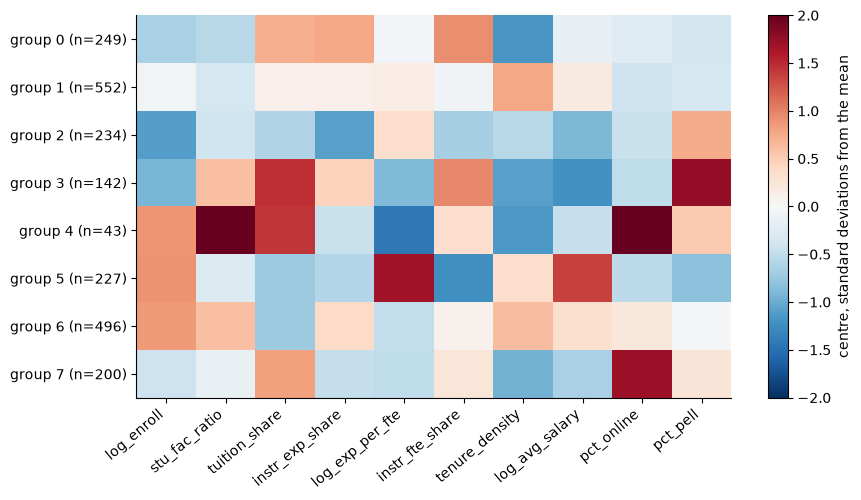

In [9]:
centres = pd.DataFrame(final.cluster_centers_, columns=X.columns)
fig, ax = plt.subplots(figsize=(9, 0.45 * K + 1.5))
im = ax.imshow(centres, cmap="RdBu_r", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(X.columns)), X.columns, rotation=40, ha="right")
ax.set_yticks(range(K), [f"group {g} (n={n})" for g, n in zip(range(K), np.bincount(labels))])
ax.grid(False)
fig.colorbar(im, ax=ax, label="centre, standard deviations from the mean")
save("05_cluster_profiles")

## 5. External validation: agreement with existing classifications

If the clusters simply reproduced control or Carnegie class, they would add nothing.
If they bore no relation to either, they would be hard to defend to a provost.

In [10]:
carnegie = groups["C21BASIC"].notna()
pd.Series({
    "ARI vs control": adjusted_rand_score(groups["CONTROL"], labels),
    "ARI vs sector": adjusted_rand_score(groups["SECTOR"], labels),
    "ARI vs 2021 Carnegie basic": adjusted_rand_score(groups.loc[carnegie, "C21BASIC"], labels[carnegie.to_numpy()]),
}).to_frame("adjusted Rand index")

,adjusted Rand index
ARI vs control,0.225
ARI vs sector,0.225
ARI vs 2021 Carnegie basic,0.107


In [11]:
top_classes = groups["C21BASIC_LABEL"].value_counts().head(8).index
pd.crosstab(groups.loc[groups["C21BASIC_LABEL"].isin(top_classes), "C21BASIC_LABEL"],
            groups.loc[groups["C21BASIC_LABEL"].isin(top_classes), "PEER_GROUP"])

PEER_GROUP,0,1,2,3,4,5,6,7
C21BASIC_LABEL,,,,,,,,
Baccalaureate Colleges: Arts & Sciences Focus,9,118,40,2,0,40,3,3
Baccalaureate Colleges: Diverse Fields,14,72,83,15,1,4,33,33
Doctoral Universities: Higher Research Activity,1,23,0,0,0,33,71,1
Doctoral Universities: Highest Research Activity,0,3,0,0,0,115,28,0
Doctoral/Professional Universities,20,87,2,2,11,3,27,24
Master's Colleges & Universities: Larger Programs,16,100,5,5,12,3,126,36
Master's Colleges & Universities: Medium Programs,21,72,6,6,1,1,43,22
Master's Colleges & Universities: Small Programs,20,51,16,6,2,3,18,25


Agreement is low: ARI 0.23 with control and 0.11 with Carnegie class. The crosstab
shows why. The operational groups cut across Carnegie classes rather than subdividing
them. Research universities split between a high-resource group (5) and a large
public group (6), and baccalaureate and master's institutions spread across several
groups. These peer groups describe how institutions are resourced and staffed, not
their mission. Present them as a complement to Carnegie peers, not a replacement.

## 6. Sensitivity: adding a block with structural missingness

Library spending per FTE is a plausible resource feature, but notebook 02 showed its
gaps are structural: institutions spending under $100K skip the detail items. The
principled encoding is a floor value plus an indicator, not an imputed median.
Institutions with no library report of their own are dropped from this variant.
If adding the block barely changes the partition, the peer groups do not depend on
how that choice is made.

In [12]:
lib = groups[["LEXP100K", "LEXPTOTF"]].copy()
lib["small_library"] = (lib["LEXP100K"] == 2).astype(float)
reported = lib["LEXPTOTF"] > 0
floor = np.log10(lib.loc[reported, "LEXPTOTF"]).min()
lib["log_lib_per_fte"] = np.where(reported, np.log10(lib["LEXPTOTF"].where(reported, 1.0)), floor)
keep = (lib["LEXP100K"].isin([1, 2]) & (reported | (lib["small_library"] == 1))).fillna(False).to_numpy(dtype=bool)
print(f"{keep.sum():,} of {len(lib):,} institutions have an own library report; "
      f"{int(lib.loc[keep, 'small_library'].sum()):,} of them are below the $100K threshold")

Z_lib = StandardScaler().fit_transform(
    np.column_stack([X.to_numpy()[keep], lib.loc[keep, ["log_lib_per_fte", "small_library"]].to_numpy()]))
lib_labels = KMeans(n_clusters=K, n_init=50, random_state=SEED).fit_predict(Z_lib)
print(f"ARI, with vs without the library block (same institutions): "
      f"{adjusted_rand_score(labels[keep], lib_labels):.2f}")

2,087 of 2,143 institutions have an own library report; 231 of them are below the $100K threshold
ARI, with vs without the library block (same institutions): 0.67


An ARI of 0.67 is a material change, well below the bootstrap median of 0.90, so the
library block moves more institutions than resampling does. Two added dimensions, one of them binary, carry real weight among only
ten. Any feature added to a peer model needs this kind of test, and the saved groups
below are explicitly the ten-feature version.

## 7. Save the peer groups

In [13]:
distance = np.linalg.norm(Z - final.cluster_centers_[labels], axis=1)
peer = pd.DataFrame({"UNITID": X.index, "PEER_GROUP": labels, "DIST_TO_CENTRE": distance,
                     "K": K, "SEED": SEED})
peer.to_parquet(ANALYTIC / "peer_groups.parquet", index=False)
print("wrote", ANALYTIC / "peer_groups.parquet", peer.shape)
peer["PEER_GROUP"].value_counts().sort_index().to_frame("institutions").T

wrote ../data/analytic/peer_groups.parquet (2143, 5)


PEER_GROUP,0,1,2,3,4,5,6,7
institutions,249,552,234,142,43,227,496,200


## Exercises

1. Replace `StandardScaler` with a robust scaler (median and IQR). Which clusters
   change, and why would heavy-tailed features behave differently?
2. Cluster public and private institutions separately. Does the within-control ARI
   against Carnegie class rise or fall?
3. Institutions far from their centre (`DIST_TO_CENTRE`) are poorly described by
   their group. List the ten farthest and decide whether they need a hand-built peer
   set.